In [2]:
data = [
    {
    "name": "example",
    "spo": {
        "yes": 100,
        "no": 50,
        "abstain": 25
    },
    "drep" : {
        "yes": 0.6,
        "no": 0.3,
        "no confidance": 0.1,
        "not voted": 0.0,

        "abstain": 0.1
    },
    "cc": {
        "yes": 0.7,
        "no": 0.2,
        "abstain": 0.1
    },
}, {"name": "example2",
    "spo": {
        "yes": 100,
        "no": 50,
        "abstain": 25
    },
    "drep" : {
        "yes": 0.6,
        "no": 0.3,
        "no confidance": 0.1,
        "not voted": 0.0,
        "abstain": 0.1
    },
    "cc": {
        "yes": 0.7,
        "no": 0.2,
        "abstain": 0.1
    }}]

In [30]:
import json

# Load from a file
with open('votes.json', 'r') as f:
    data = json.load(f)


def calc_abstain_pct(group_data,cc=False):
    abstain = group_data.get("abstain", 0)
    total = sum(group_data.values())
    if cc:
        total = 7
    return abstain / total if total > 0 else 0

# Compute abstain percentages
cc_pct = np.array([calc_abstain_pct(entry["cc"],cc=True) for entry in data])
drep_pct = np.array([calc_abstain_pct(entry["drep"]) for entry in data])
spo_pct = np.array([calc_abstain_pct(entry["spo"]) for entry in data])

# Compute 10th and 90th percentiles
cc_bounds = np.quantile(cc_pct, [0.1, 0.9])
drep_bounds = np.quantile(drep_pct, [0.1, 0.9])
spo_bounds = np.quantile(spo_pct, [0.1, 0.9])

# Filter to include only values within [10th, 90th] percentiles
cc_filtered = cc_pct[(cc_pct >= cc_bounds[0]) & (cc_pct <= cc_bounds[1])]
drep_filtered = drep_pct[(drep_pct >= drep_bounds[0]) & (drep_pct <= drep_bounds[1])]
spo_filtered = spo_pct[(spo_pct >= spo_bounds[0]) & (spo_pct <= spo_bounds[1])]

# Compute and print the mean
print("Average abstain percentage (10th to 90th percentile):")
print(f"  CC:   {cc_filtered.mean() * 100:.2f}%")
print(f"  DRep: {drep_filtered.mean() * 100:.2f}%")
print(f"  SPO:  {spo_filtered.mean() * 100:.2f}%")



Average abstain percentage (10th to 90th percentile):
  CC:   9.82%
  DRep: 39.94%
  SPO:  66.03%


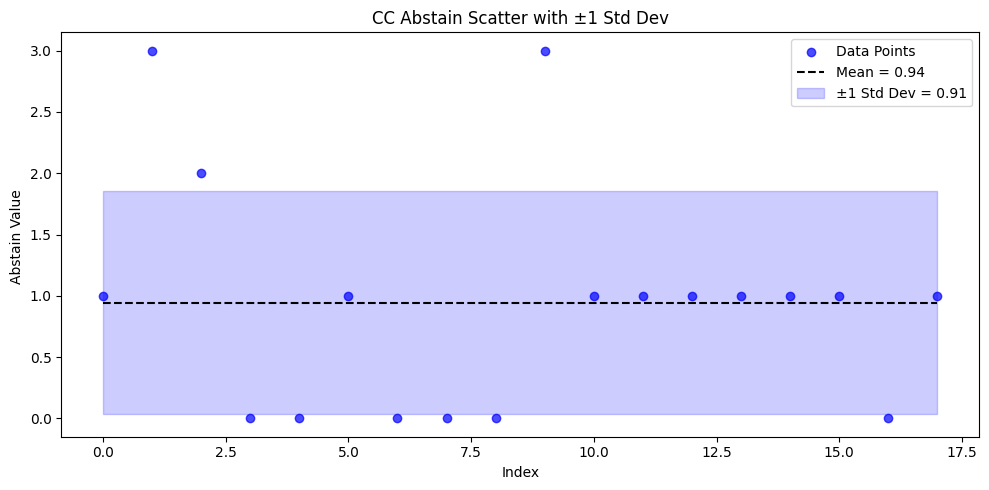

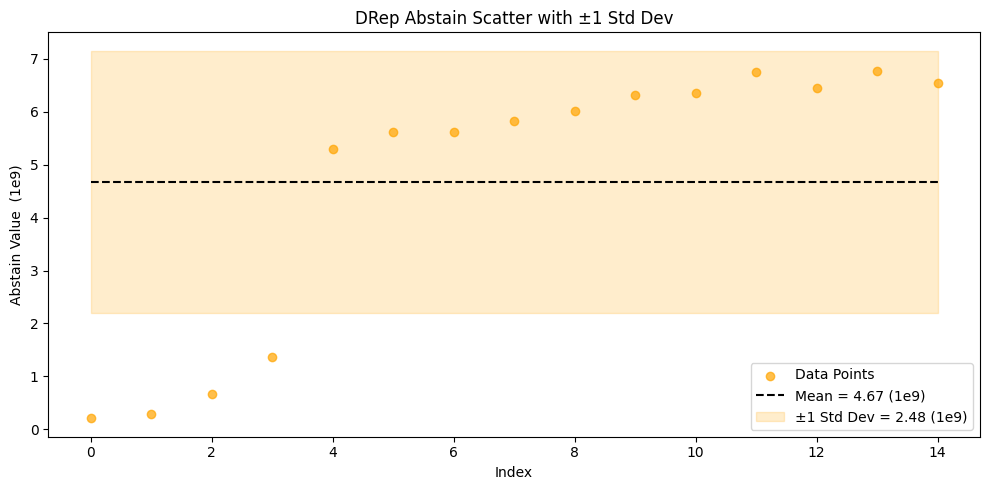

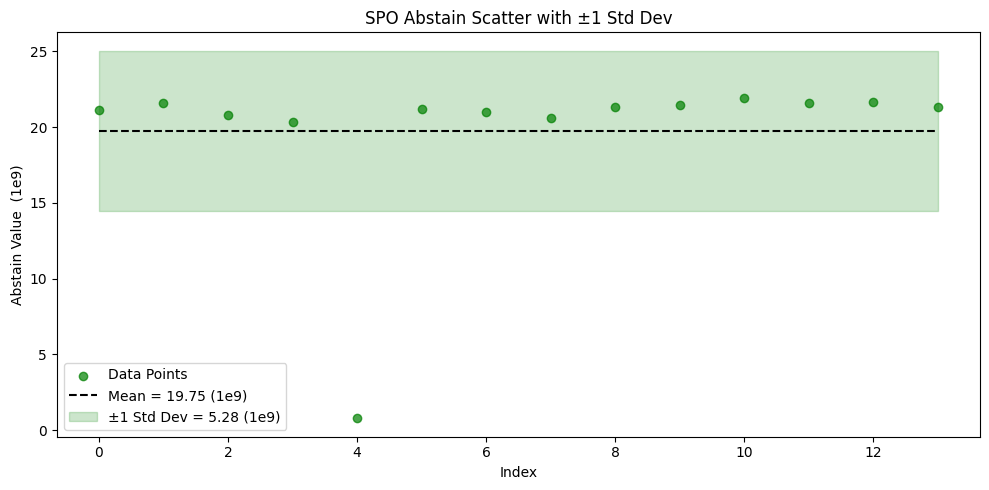

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data
cc_abstain = [
    item['cc']['abstain']
    for item in data
    if any(value != 0 for value in item['cc'].values())
]

drep_abstain = [
    item['drep']['abstain']
    for item in data
    if any(value != 0 for value in item['drep'].values())
]

spo_abstain = [
    item['spo']['abstain']
    for item in data
    if any(value != 0 for value in item['spo'].values())
]


# Scale drep and spo abstain to millions for easier reading
drep_abstain_m = np.array(drep_abstain) / 1e3
spo_abstain_m = np.array(spo_abstain) / 1e3

def plot_scatter_with_std(data, color, title, scale_label=''):
    x = np.arange(len(data))
    mean = np.mean(data)
    std = np.std(data)

    plt.figure(figsize=(10, 5))
    plt.scatter(x, data, color=color, alpha=0.7, label='Data Points')
    plt.plot(x, [mean]*len(x), color='black', linestyle='--', label=f'Mean = {mean:.2f}{scale_label}')
    plt.fill_between(x, mean - std, mean + std, color=color, alpha=0.2, label=f'±1 Std Dev = {std:.2f}{scale_label}')
    plt.title(title)
    plt.xlabel('Index')
    plt.ylabel(f'Abstain Value {scale_label}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot each in a separate graph
plot_scatter_with_std(cc_abstain, 'blue', 'CC Abstain Scatter with ±1 Std Dev', '')
plot_scatter_with_std(drep_abstain_m, 'orange', 'DRep Abstain Scatter with ±1 Std Dev', ' (1e9)')
plot_scatter_with_std(spo_abstain_m, 'green', 'SPO Abstain Scatter with ±1 Std Dev', ' (1e9)')


Mean CC Abstain: 0.9444
Mean DRep Abstain: 4.6708 (1e9)
Mean SPO Abstain: 19.7539 (1e9)


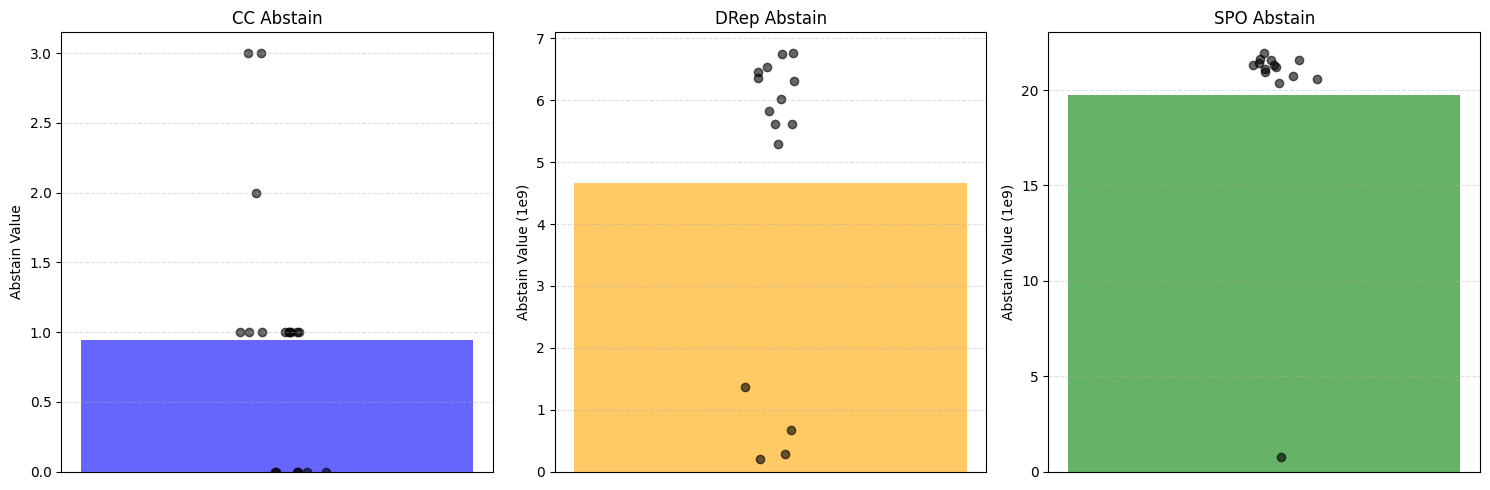

In [42]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

groups = [
    ('CC', cc_abstain, 'blue', ''),
    ('DRep', drep_abstain_m, 'orange', ' (1e9)'),
    ('SPO', spo_abstain_m, 'green', ' (1e9)')
]

for i, (label, values, color, unit) in enumerate(groups):
    axs[i].bar(0, np.mean(values), color=color, alpha=0.6, label='Mean')
    axs[i].scatter(np.random.normal(0, 0.05, len(values)), values, color="black", alpha=0.6)
    axs[i].set_title(f'{label} Abstain')
    axs[i].set_ylabel(f'Abstain Value{unit}')
    axs[i].set_xticks([])
    axs[i].grid(axis='y', linestyle='--', alpha=0.4)
    print(f"Mean {label} Abstain: {np.mean(values):.4f}{unit}")

# plt.suptitle('Abstain by Group with Individual Values (Separate Y-Axes)', fontsize=14)
plt.tight_layout()
plt.savefig('abstain_by_group.pdf', dpi=300)
plt.show()


In [43]:
cc_abstain_pct = [
    item['cc']['abstain'] / sum(item['cc'].values())
    for item in data
    if sum(item['cc'].values()) != 0
]

drep_abstain_pct = [
    item['drep']['abstain'] / sum(item['drep'].values())
    for item in data
    if sum(item['drep'].values()) != 0
]

spo_abstain_pct = [
    item['spo']['abstain'] / sum(item['spo'].values())
    for item in data
    if sum(item['spo'].values()) != 0
]

print("Average abstain values:")
print(f"  CC:   {0.94/7}")
print(f"  DRep: {np.mean(drep_abstain_pct):.4f}")
print(f"  SPO:  {np.mean(spo_abstain_pct):.4f}")

Average abstain values:
  CC:   0.13428571428571429
  DRep: 0.5050
  SPO:  0.8964
